KNN Classification Mini Project — Student Performance Prediction
🎯 Goal

Predict whether a student will Pass (1) or Fail (0) using:

Study_Hours
Previous_Score

In [1]:
# Import pandas for creating and handling the dataset
import pandas as pd

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Import KNN Classification model
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Create a simple student dataset
data = {
    "Study_Hours": [
        1, 2, 2, 3, 3,
        4, 4, 5, 5, 6,
        6, 7, 7, 8, 8,
        9, 9, 10, 10, 11
    ],

    "Previous_Score": [
        35, 40, 45, 42, 48,
        50, 55, 58, 60, 62,
        65, 68, 70, 72, 75,
        78, 82, 85, 90, 94
    ],

    # 0 = Fail
    # 1 = Pass
    "Result": [
        0, 0, 0, 0, 0,
        0, 0, 0, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

# Convert dictionary into a pandas DataFrame
df = pd.DataFrame(data)

# Display the complete dataset
df.head(5)

,Study_Hours,Previous_Score,Result
0,1,35,0
1,2,40,0
2,2,45,0
3,3,42,0
4,3,48,0


In [4]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     20 non-null     int64
 1   Previous_Score  20 non-null     int64
 2   Result          20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


In [5]:
# Display statistical summary
df.describe()

,Study_Hours,Previous_Score,Result
count,20.000000,20.000000,20.000000
mean,6.000000,63.700000,0.600000
std,2.991215,17.204956,0.502625
min,1.000000,35.000000,0.000000
25%,3.750000,49.500000,0.000000
50%,6.000000,63.500000,1.000000
75%,8.250000,75.750000,1.000000
max,11.000000,94.000000,1.000000


In [6]:
# Check the number of missing values in each column
df.isnull().sum()

Study_Hours       0
Previous_Score    0
Result            0
dtype: int64

In [7]:
# Features are the input columns used for prediction
X = df[["Study_Hours", "Previous_Score"]]

# Target is the value we want to predict
y = df["Result"]

# Display features
print("Features:")
print(X)

# Display target
print("\nTarget:")
print(y)

Features:
    Study_Hours  Previous_Score
0             1              35
1             2              40
2             2              45
3             3              42
4             3              48
5             4              50
6             4              55
7             5              58
8             5              60
9             6              62
10            6              65
11            7              68
12            7              70
13            8              72
14            8              75
15            9              78
16            9              82
17           10              85
18           10              90
19           11              94

Target:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
Name: Result, dtype: int64


In [8]:
# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the number of samples
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16
Testing samples: 4


In [9]:
# Create StandardScaler object
scaler = StandardScaler()

# Learn scaling parameters from training data
# and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the SAME scaler
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [10]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Create KNN classification model
# K = 3 means the model looks at 3 nearest students
model = KNeighborsClassifier(n_neighbors=3)

# Display model
print(model)

KNeighborsClassifier(n_neighbors=3)


In [12]:
# Train the KNN model using scaled training data
model.fit(X_train_scaled, y_train)

print("KNN Classification model trained successfully!")

KNN Classification model trained successfully!


In [13]:
# Predict results for test data
y_pred = model.predict(X_test_scaled)

# Display predictions
print("Predicted Results:")
print(y_pred)

Predicted Results:
[0 0 1 1]


In [14]:
# Create a comparison DataFrame
comparison = pd.DataFrame({
    "Actual Result": y_test.values,
    "Predicted Result": y_pred
})

# Display comparison
comparison

,Actual Result,Predicted Result
0,0,0
1,0,0
2,1,1
3,1,1


In [15]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


In [16]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2 0]
 [0 2]]


In [17]:
# Display precision, recall and F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



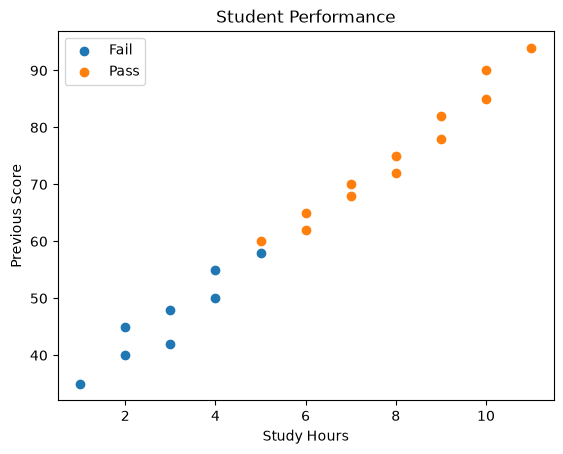

In [18]:
# Create separate data for Fail students
fail_students = df[df["Result"] == 0]

# Create separate data for Pass students
pass_students = df[df["Result"] == 1]

# Plot Fail students
plt.scatter(
    fail_students["Study_Hours"],
    fail_students["Previous_Score"],
    label="Fail"
)

# Plot Pass students
plt.scatter(
    pass_students["Study_Hours"],
    pass_students["Previous_Score"],
    label="Pass"
)

# Add labels
plt.xlabel("Study Hours")
plt.ylabel("Previous Score")

# Add title
plt.title("Student Performance")

# Show legend
plt.legend()

# Display plot
plt.show()

In [19]:
# Create data for a new student
new_student = [[6.5, 67]]

# Scale the new student using the already-fitted scaler
new_student_scaled = scaler.transform(new_student)

# Make prediction
prediction = model.predict(new_student_scaled)

# Display prediction
if prediction[0] == 1:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")

Prediction: PASS


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
# Get probability for each class
probability = model.predict_proba(new_student_scaled)

# Display probabilities
print("Class probabilities:")
print(probability)

# Display class order
print("Classes:", model.classes_)

Class probabilities:
[[0. 1.]]
Classes: [0 1]


In [21]:
# Find the 3 nearest training students
distances, indices = model.kneighbors(new_student_scaled)

# Display distances
print("Distances:")
print(distances)

# Display nearest students
print("\nNearest Students:")
print(X_train.iloc[indices[0]])

# Display their actual results
print("\nTheir Results:")
print(y_train.iloc[indices[0]].values)

Distances:
[[0.18102258 0.20843579 0.2474658 ]]

Nearest Students:
    Study_Hours  Previous_Score
11            7              68
10            6              65
12            7              70

Their Results:
[1 1 1]
